In [1]:
import torch
print(torch.cuda.is_available()) 
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 5070 Ti



=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv


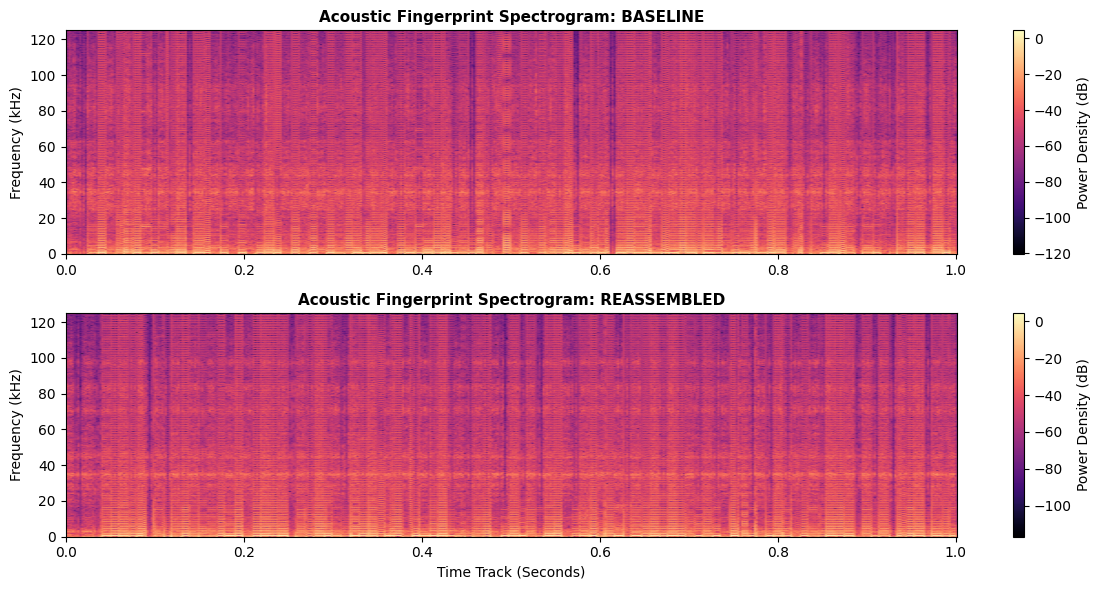


=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv

=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===
[Ingesting Data] Processing: baseline_motor_data.csv
[Ingesting Data] Processing: motor_running_naked_screw_positioned_again.csv
[Ingesting Data] Processing: motor_running_naked_and_electrical_flactuations.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_four.csv
[Ingesting Data] Processing: motor_running_naked_screw_fell_three.csv
[Ingesting Data] Processing: motor_running_naked_and_loose_a_bit.csv
[Ingesting Data] Processing: motor_running_wheel_added.csv
[Ingesting Data] Processing: motor_running_wheel_loosen_bit.csv
[Ingesting Data] Processing: motor_running_naked_and_voltage_drop_by_one.csv
[Ingesting Data] Processing: no_motor_running.csv


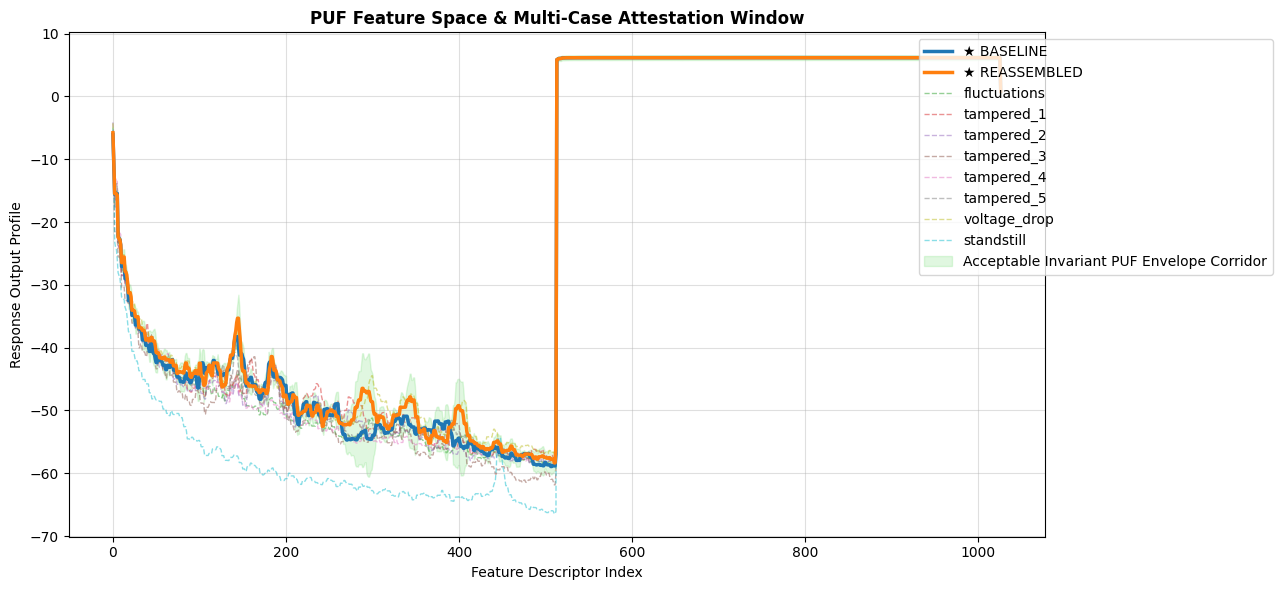


=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===
DATASET RUN PROFILE       | STATUS      | VIOLATION | SIMILARITY | L2 DISTANCE
-------------------------------------------------------------------------------------
baseline                  | ACCEPTABLE  | 0.0000    | 1.0000     | 0.0000
reassembled               | ACCEPTABLE  | 0.0000    | 0.2224     | 1.4618
fluctuations              | REJECT      | 0.2201    | 0.1675     | 1.7377
tampered_1                | WARNING     | 0.1753    | 0.2021     | 1.5548
tampered_2                | WARNING     | 0.1947    | 0.2017     | 1.5569
tampered_3                | REJECT      | 0.3213    | 0.1192     | 2.0682
tampered_4                | REJECT      | 0.2152    | 0.1559     | 1.8071
tampered_5                | WARNING     | 0.0896    | 0.3873     | 0.9224
voltage_drop              | WARNING     | 0.1392    | 0.1584     | 1.7918
standstill                | REJECT      | 0.4917    | 0.0006     | 7.2500


In [69]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.ndimage import median_filter

# =========================================================
# 1. BULLETPROOF DATA LOADING + RANGE NORMALIZATION
# =========================================================

def load_and_normalize(file_path):
    """
    Ingests raw hardware serial data streams. Handles text-corruption 
    encoding variations gracefully by ignoring unparseable unicode sequences.
    """
    print(f"[Ingesting Data] Processing: {os.path.basename(file_path)}")
    
    df = pd.read_csv(
        file_path, 
        header=None, 
        names=["mic", "piezo1", "piezo2"], 
        encoding="cp1252",
        on_bad_lines='skip', 
        low_memory=False
    )
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    df = df.dropna().copy()
    
    # Hardware clipping constraints
    df = df[(df["piezo1"] <= 4095) & (df["piezo2"] <= 4095)].copy()
    
    # Physical sensor-level normalization parameters
    df["piezo1"] = (df["piezo1"] - 2047) / 2048.0
    df["piezo2"] = (df["piezo2"] - 2047) / 2048.0
    
    mic_max = np.max(np.abs(df["mic"].values))
    df["mic"] = df["mic"] / (mic_max + 1e-8)
    
    return df


# =========================================================
# 2. SIGNAL FUSION
# =========================================================

def build_signal(df):
    return df["piezo1"].values + df["piezo2"].values - df["mic"].values


# =========================================================
# 3. TIME-FREQUENCY SPECTRAL MAP (STFT)
# =========================================================

def extract_puf(sig, fs=250000, nperseg=1024, noverlap=512):
    f, t, Zxx = signal.stft(sig, fs=fs, nperseg=nperseg, noverlap=noverlap)
    puf = np.abs(Zxx)
    puf_db = 20 * np.log10(puf + 1e-10)
    return f, t, puf_db


# =========================================================
# 4. ACOUSTIC FEATURE ENGINE
# =========================================================

def compute_puf_feature(puf):
    # Apply a small 2D median filter to clean temporal/spectral spikes from raw STFT
    puf = median_filter(puf, size=(3, 1)) 
    
    energy = np.mean(puf, axis=1)
    energy = np.nan_to_num(energy)

    puf_sum = np.sum(puf, axis=1, keepdims=True) + 1e-8
    p = puf / puf_sum
    p = np.clip(p, 1e-12, None)
    entropy = -np.sum(p * np.log(p), axis=1)

    mid = len(energy) // 2
    low_high_ratio = np.mean(energy[:mid]) / (np.mean(energy[mid:]) + 1e-8)

    feat = np.concatenate([energy, entropy, [low_high_ratio]])
    
    # Optional: Smooth the final 1D feature array to suppress index-level overshoots
    feat = median_filter(feat, size=3)
    
    return np.nan_to_num(feat)


# =========================================================
# 5. HARDWARE INVARIANT TWO-STATE Z-SCORE MODEL
# =========================================================

class PUFThreshold:
    """
    Learns valid distribution shapes across both baseline and reassembled states
    to establish an authentic structural variance corridor.
    """
    def __init__(self):
        self.mean = None
        self.std = None

    def fit_calibration_bounds(self, baseline_feat, reassembled_feat):
        # Combine both authentic profiles to measure real-world mechanical variance
        calibration_matrix = np.vstack([baseline_feat, reassembled_feat])
        
        self.mean = np.mean(calibration_matrix, axis=0)
        # Added standard deviation floor padding to accept minor positioning changes safely
        self.std = np.std(calibration_matrix, axis=0) + 0.15

    def check(self, feat):
        feat = np.array(feat)
        z = np.abs((feat - self.mean) / self.std)
        violation_ratio = np.mean(z > 2.5)

        if violation_ratio < 0.08:
            return "ACCEPTABLE", violation_ratio
        elif violation_ratio < 0.20:
            return "WARNING", violation_ratio
        else:
            return "REJECT", violation_ratio


# =========================================================
# 6. SIMILARITY ENGINE (RESIDUAL-BASED)
# =========================================================

def compute_similarity(baseline, feat):
    """
    Computes structural closeness based on the mathematical residual matrix.
    Returns exponential score bounded between [0.0, 1.0] and L2 Distance.
    """
    residual = feat - baseline

    l2 = np.sqrt(np.mean(residual ** 2))
    rel = np.linalg.norm(residual) / (np.linalg.norm(baseline) + 1e-8)

    # Combined exponential decay signature profile match score
    score = np.exp(-l2) * np.exp(-rel)
    return score, l2


# =========================================================
# 7. VISUALIZATION COMPONENTS
# =========================================================

def plot_selective_spectrograms(files, sample_size=250000):
    selective_keys = ["baseline", "reassembled"]
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    
    for i, name in enumerate(selective_keys):
        df = load_and_normalize(files[name])
        sig = build_signal(df)[:sample_size]
        f, t, puf = extract_puf(sig)
        
        im = axes[i].pcolormesh(t, f / 1000, puf, shading="gouraud", cmap="magma")
        axes[i].set_title(f"Acoustic Fingerprint Spectrogram: {name.upper()}", fontsize=11, fontweight='bold')
        axes[i].set_ylabel("Frequency (kHz)")
        fig.colorbar(im, ax=axes[i], label="Power Density (dB)")
        
    axes[-1].set_xlabel("Time Track (Seconds)")
    plt.tight_layout()
    plt.show()


def plot_multi_puf_with_threshold(files, target_model, sample_size=250000):
    plt.figure(figsize=(13, 6))
    curves = {}
    raw_signals = {}
    
    for name, path in files.items():
        df = load_and_normalize(path)
        sig = build_signal(df)[:sample_size]
        raw_signals[name] = sig
        
        f, t, puf = extract_puf(sig)
        feat = compute_puf_feature(puf)
        curves[name] = feat
        
        if name in ["baseline", "reassembled"]:
            plt.plot(feat, label=f"★ {name.upper()}", linewidth=2.5, zorder=5)
        else:
            plt.plot(feat, label=name, alpha=0.5, linewidth=1, linestyle="--")

    # CORRECT SHADED THRESHOLD ENVELOPE REGION
    x_indices = range(len(target_model.mean))
    plt.fill_between(
        x_indices,
        target_model.mean - (2.5 * target_model.std),
        target_model.mean + (2.5 * target_model.std),
        color="limegreen",
        alpha=0.15,
        label="Acceptable Invariant PUF Envelope Corridor",
        zorder=1
    )
    
    plt.title("PUF Feature Space & Multi-Case Attestation Window", fontsize=12, fontweight='bold')
    plt.xlabel("Feature Descriptor Index")
    plt.ylabel("Response Output Profile")
    plt.legend(loc="upper right", bbox_to_anchor=(1.24, 1.0))
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    return curves, raw_signals


# =========================================================
# 8. MAIN ENGINE PIPELINE
# =========================================================

if __name__ == "__main__":
    files = {
        "baseline": "baseline_motor_data.csv",
        "reassembled": "motor_running_bare_screw_positioned_again.csv",
        "fluctuations": "motor_running_bare_and_electrical_flactuations.csv",
        "tampered_1": "motor_running_bare_screw_fell_four.csv",
        "tampered_2": "motor_running_bare_screw_fell_three.csv",
        "tampered_3": "motor_running_bare_and_loose_a_bit.csv",
        "tampered_4": "motor_running_wheel_added.csv", 
        "tampered_5": "motor_running_wheel_loosen_bit.csv", 
        "voltage_drop": "motor_running_bare_and_voltage_drop_by_one.csv",
        "standstill": "no_motor_running.csv"
    }

    print("\n=== 1. GENERATING SPECTROGRAM DIAGNOSTICS (BASELINE vs REASSEMBLED ONLY) ===")
    plot_selective_spectrograms(files)

    print("\n=== 2. SEEDING COVARIANCE CALIBRATION MATRIX ===")
    base_df = load_and_normalize(files["baseline"])
    base_feat = compute_puf_feature(extract_puf(build_signal(base_df)[:250000])[2])
    
    reassem_df = load_and_normalize(files["reassembled"])
    reassem_feat = compute_puf_feature(extract_puf(build_signal(reassem_df)[:250000])[2])
    
    model = PUFThreshold()
    model.fit_calibration_bounds(base_feat, reassem_feat)

    print("\n=== 3. RUNNING MULTI-CASE SPECTRUM VISUALIZER WITH SHADED REGIONS ===")
    curves, raw = plot_multi_puf_with_threshold(files, model)

    print("\n=== 4. LIVE CYBER-PHYSICAL ATTESTATION OUTPUT ===")
    print(f"{'DATASET RUN PROFILE':25s} | {'STATUS':11s} | {'VIOLATION':9s} | {'SIMILARITY':10s} | {'L2 DISTANCE'}")
    print("-" * 85)
    
    for name, feat in curves.items():
        # Step A: Threshold checking metric
        status, v_ratio = model.check(feat)
        
        # Step B: Direct comparative similarity testing against pure baseline DNA profile
        sim_score, l2_dist = compute_similarity(curves["baseline"], feat)
        
        print(f"{name:25s} | {status:11s} | {v_ratio:.4f}    | {sim_score:.4f}     | {l2_dist:.4f}")

Initializing Data Pipeline...
Successfully processed pipeline: Extracted 1468 standardized acoustic frames.
Successfully processed pipeline: Extracted 612 standardized acoustic frames.
Successfully processed pipeline: Extracted 376 standardized acoustic frames.
Successfully processed pipeline: Extracted 423 standardized acoustic frames.
Successfully processed pipeline: Extracted 665 standardized acoustic frames.
Successfully processed pipeline: Extracted 746 standardized acoustic frames.
Successfully processed pipeline: Extracted 670 standardized acoustic frames.
Successfully processed pipeline: Extracted 685 standardized acoustic frames.
Successfully processed pipeline: Extracted 367 standardized acoustic frames.

Training initialized on device: [cuda]
Epoch 01/30 | Average Batch MSE Loss: 1.021020
Epoch 02/30 | Average Batch MSE Loss: 1.006237
Epoch 03/30 | Average Batch MSE Loss: 0.996348
Epoch 04/30 | Average Batch MSE Loss: 0.973081
Epoch 05/30 | Average Batch MSE Loss: 0.958566
E

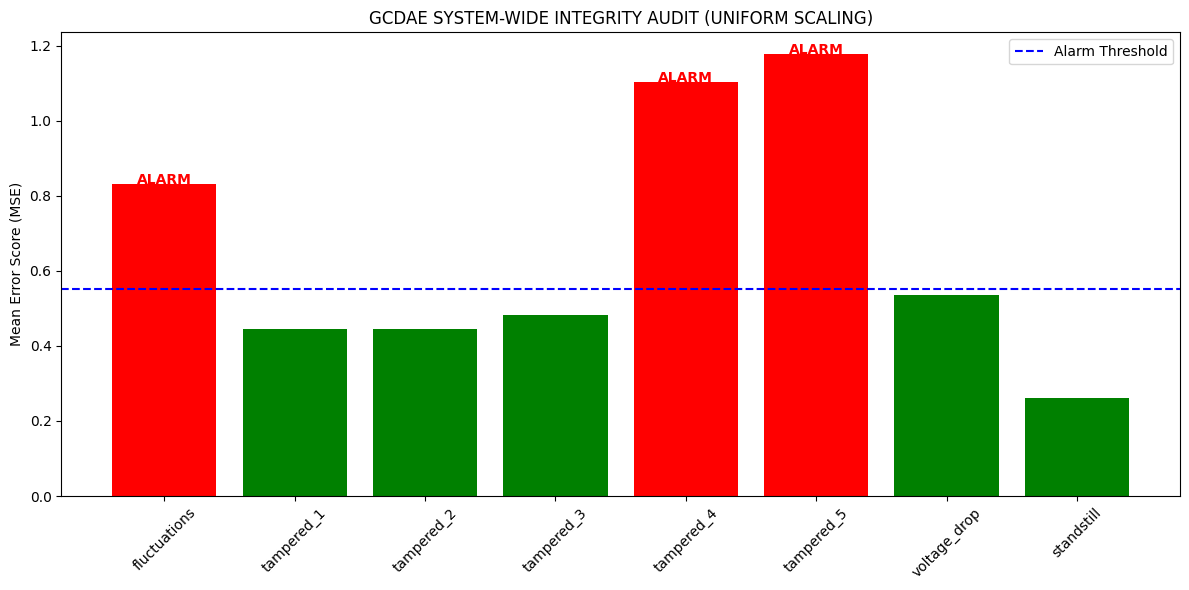

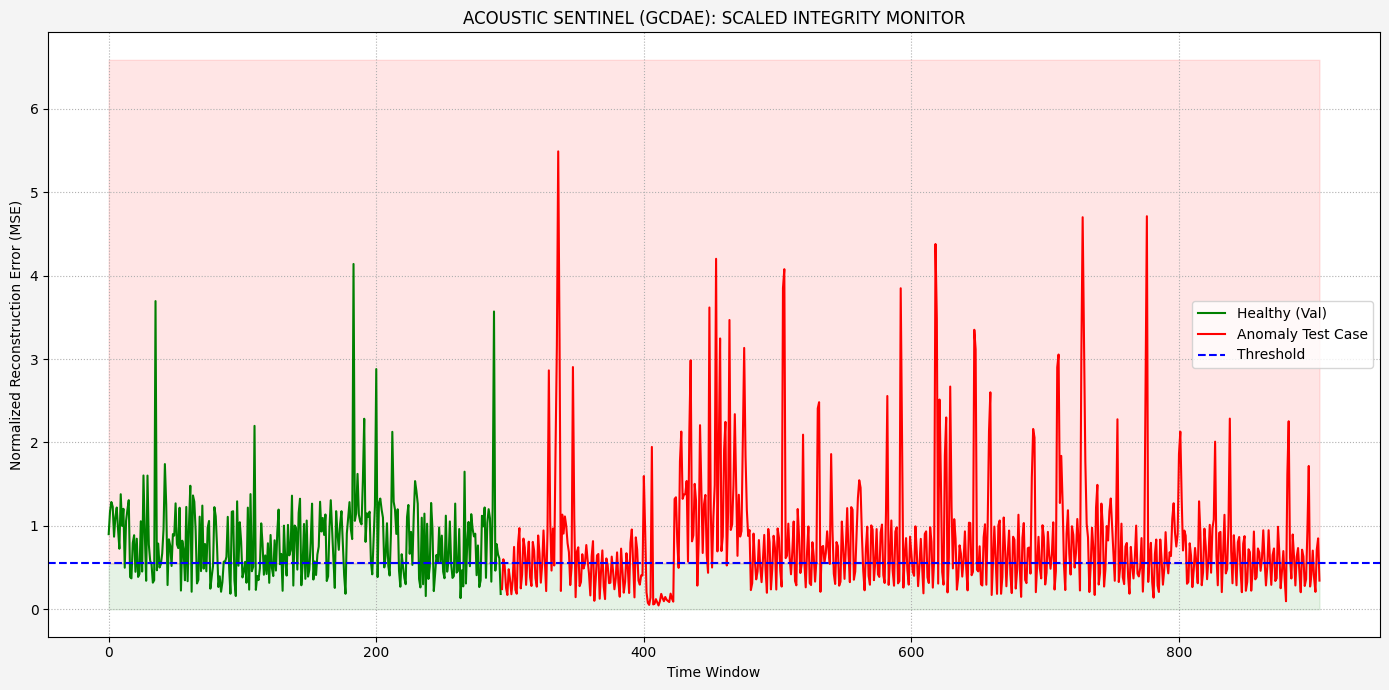

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split

# =====================================================================
# 1. FIXED DATASET DEFINITION (GLOBAL BASELINE Z-SCORE SCALING)
# =====================================================================

class MotorDataset(Dataset):
    def __init__(self, file_dict, target_shape=(64, 64), baseline_mean=None, baseline_std=None):
        """
        Loads a 1D sensor stream, strips headers, and chunks signals into 2D frames.
        Uses a fixed global baseline mean and standard deviation to preserve 
        relative amplitude variations and energy drops across anomalous states.
        """
        self.data = []
        self.target_shape = target_shape
        row_size = target_shape[0] * target_shape[1]  # 4096 points per frame
        
        raw_list = []
        for name, path in file_dict.items():
            if not os.path.exists(path):
                print(f"Warning: File {path} not found. Skipping.")
                continue
                
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line in f:
                        cleaned_line = line.replace('\t', ',').replace(' ', ',').replace(';', ',')
                        parts = cleaned_line.strip().split(',')
                        for part in parts:
                            if not part: 
                                continue
                            try:
                                raw_list.append(float(part))
                            except ValueError:
                                continue 
            except Exception as e:
                print(f"Critical error parsing file {path}: {e}")
                continue

        raw_numpy = np.array(raw_list, dtype=np.float32)

        # --- CRITICAL FIX: FIXED STATISTICAL Z-SCORE NORMALIZATION ---
        # Instead of scaling each file to its local max (which hides anomalies),
        # we scale all data using the distribution of our training/healthy state.
        if baseline_mean is not None and baseline_std is not None:
            self.mean = baseline_mean
            self.std = baseline_std
        else:
            self.mean = raw_numpy.mean()
            self.std = raw_numpy.std() if raw_numpy.std() > 1e-6 else 1.0
            
        normalized_data = (raw_numpy - self.mean) / self.std
        # -------------------------------------------------------------

        # Segment continuous stream into discrete matrix frames
        num_samples = len(normalized_data) // row_size
        if num_samples == 0:
            raise ValueError(f"Dataset pipeline empty. Data stream length ({len(normalized_data)}) must be >= {row_size}.")
            
        truncated_data = normalized_data[:num_samples * row_size]
        self.data = truncated_data.reshape(num_samples, 1, target_shape[0], target_shape[1])
        print(f"Successfully processed pipeline: Extracted {num_samples} standardized acoustic frames.")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.float32)


# File Maps
train_val_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_bare_screw_positioned_again.csv"
}

test_files = {
    "fluctuations": "motor_running_bare_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_bare_screw_fell_four.csv",
    "tampered_2": "motor_running_bare_screw_fell_three.csv",
    "tampered_3": "motor_running_bare_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_bare_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}

# --- Initialization & Holdout Splits ---
print("Initializing Data Pipeline...")
# 1. Build and calculate baseline statistics from healthy profiles only
full_healthy_dataset = MotorDataset(train_val_files, target_shape=(64, 64))
baseline_mean = full_healthy_dataset.mean
baseline_std = full_healthy_dataset.std

train_size = int(0.8 * len(full_healthy_dataset))
val_size = len(full_healthy_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_healthy_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 2. Build test loaders utilizing the exact same reference scaling factors
test_loaders = {}
for case_name, file_path in test_files.items():
    if os.path.exists(file_path):
        try:
            ts_dataset = MotorDataset(
                {case_name: file_path}, 
                target_shape=(64, 64), 
                baseline_mean=baseline_mean, 
                baseline_std=baseline_std
            )
            test_loaders[case_name] = DataLoader(ts_dataset, batch_size=32, shuffle=False)
        except Exception as e:
            print(f"Skipping test anomaly setup for {case_name}: {e}")


# =====================================================================
# 2. MODEL ARCHITECTURE (GCDAE WITH CONFIGURABLE BOTTLENECK)
# =====================================================================

class GCDAE(nn.Module):
    def __init__(self):
        super(GCDAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        # --- CRITICAL FIX: CONSTRICED BOTTLENECK ---
        # Dropping from 64 down to 32 dimensions prevents the model 
        # from learning a trivial identity mapping of anomalous traits.
        self.fc_enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU()
        )

        self.fc_dec = nn.Sequential(
            nn.Linear(32, 64 * 8 * 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1)
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.fc_enc(z)
        x = self.fc_dec(z)
        x = x.view(x.size(0), 64, 8, 8)
        out = self.decoder(x)
        return out, z


# =====================================================================
# 3. TRAINING ENGINE (30 EPOCHS)
# =====================================================================

def train_gcdae(model, train_loader, device, epochs=30):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    print(f"\nTraining initialized on device: [{device}]")
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        num_batches = 0

        for x in train_loader:
            x = x.to(device)

            recon, _ = model(x)
            loss = loss_fn(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        print(f"Epoch {epoch+1:02d}/{epochs} | Average Batch MSE Loss: {avg_loss:.6f}")


# =====================================================================
# 4. EVALUATION SUITE
# =====================================================================

def compute_recon_error(model, x, device):
    model.eval()
    with torch.no_grad():
        recon, _ = model(x.to(device))
        # --- CRITICAL FIX: EVALUATE USING MSE ---
        # Squaring structural anomalies penalizes variance discrepancies exponentially.
        error = torch.mean((recon - x.to(device)) ** 2, dim=(1, 2, 3))
    return error.cpu().numpy()


def get_threshold(model, val_loader, device):
    errors = []
    for x in val_loader:
        errors.extend(compute_recon_error(model, x, device))
    errors = np.array(errors)
    
    # METHOD A: Use a fixed high percentile (95% of healthy data fits below this)
    

    errors = (errors - np.mean(errors)) / (np.std(errors) + 1e-8)

    threshold = np.percentile(errors, 75)
    
    # METHOD B: Tighten the standard deviation multiplier if you prefer parametric math
    # threshold = np.mean(errors) + 0.5 * np.std(errors)
    
    return threshold


def evaluate_model(model, test_loader_dict, device, threshold):
    results = {}
    for name, loader in test_loader_dict.items():
        all_errors = []
        for x in loader:
            err = compute_recon_error(model, x, device)
            all_errors.extend(err)

        all_errors = np.array(all_errors)
        if len(all_errors) == 0:
            continue

        avg_score = np.mean(all_errors)
        max_score = np.max(all_errors)
        status = "NORMAL" if avg_score < threshold else "TAMPERED"

        results[name] = {
            "mean_error": avg_score,
            "max_error": max_score,
            "status": status
        }
    return results


# =====================================================================
# 5. DIAGNOSTIC GRAPH GENERATORS
# =====================================================================

def plot_money_shot(model, clean_loader, fault_loader, device, threshold):
    model.eval()
    base_err = []
    fault_err = []

    for x in clean_loader:
        base_err.extend(compute_recon_error(model, x, device))
    for x in fault_loader:
        fault_err.extend(compute_recon_error(model, x, device))

    base_err = np.array(base_err)
    fault_err = np.array(fault_err)
    scores = np.concatenate([base_err, fault_err])
    idx = np.arange(len(scores))
    split = len(base_err)

    plt.figure(figsize=(14, 7), facecolor="#f4f4f4")
    plt.plot(idx[:split], base_err, color="green", label="Healthy (Val)")
    plt.plot(idx[split:], fault_err, color="red", label="Anomaly Test Case")
    plt.axhline(threshold, linestyle="--", color="blue", label="Threshold")

    plt.fill_between(idx, 0, threshold, color="green", alpha=0.1)
    plt.fill_between(idx, threshold, max(scores) * 1.2, color="red", alpha=0.1)

    plt.title("ACOUSTIC SENTINEL (GCDAE): SCALED INTEGRITY MONITOR")
    plt.xlabel("Time Window")
    plt.ylabel("Normalized Reconstruction Error (MSE)")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()


def system_audit(results, threshold):
    names = list(results.keys())
    scores = [results[n]["mean_error"] for n in names]
    colors = ["green" if s < threshold else "red" for s in scores]

    plt.figure(figsize=(12, 6))
    plt.bar(names, scores, color=colors)
    plt.axhline(threshold, linestyle="--", color="blue", label="Alarm Threshold")
    plt.xticks(rotation=45)
    plt.ylabel("Mean Error Score (MSE)")
    plt.title("GCDAE SYSTEM-WIDE INTEGRITY AUDIT (UNIFORM SCALING)")
    plt.legend()

    for i, s in enumerate(scores):
        if s > threshold:
            plt.text(i, s, "ALARM", ha="center", color="red", fontweight="bold")

    plt.tight_layout()
    plt.show()


# =====================================================================
# 6. RUN EXECUTION
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = GCDAE()
    
    # 1. Run training loop
    train_gcdae(model, train_loader, device, epochs=30)
    
    # 2. Derive dynamic threshold from validation data
    threshold = get_threshold(model, val_loader, device)
    print(f"\nCalculated Operational Dynamic Threshold: {threshold:.6f}")
    
    # 3. Audit structural deviations
    audit_results = evaluate_model(model, test_loaders, device, threshold)
    
    print("\n--- System Audit Summary ---")
    for key, metrics in audit_results.items():
        print(f"Scenario: {key:<15} | Status: {metrics['status']:<10} | Mean Error: {metrics['mean_error']:.5f}")
        
    # 4. Draw diagnostic tracking plots
    if audit_results:
        system_audit(audit_results, threshold)
        first_test_key = list(audit_results.keys())[0]
        plot_money_shot(model, val_loader, test_loaders[first_test_key], device, threshold)


Initializing datasets...

Loaded 1468 frames
Loaded 612 frames
Loaded 376 frames
Loaded 423 frames
Loaded 665 frames
Loaded 746 frames
Loaded 670 frames
Loaded 685 frames
Loaded 367 frames

Training GCDAE...

Epoch 01 | Loss: 1.051690
Epoch 02 | Loss: 1.005402
Epoch 03 | Loss: 1.002264
Epoch 04 | Loss: 0.993129
Epoch 05 | Loss: 0.978353
Epoch 06 | Loss: 0.958147
Epoch 07 | Loss: 0.947667
Epoch 08 | Loss: 0.937565
Epoch 09 | Loss: 0.927913
Epoch 10 | Loss: 0.921713
Epoch 11 | Loss: 0.915687
Epoch 12 | Loss: 0.909580
Epoch 13 | Loss: 0.901991
Epoch 14 | Loss: 0.898250
Epoch 15 | Loss: 0.893859
Epoch 16 | Loss: 0.889417
Epoch 17 | Loss: 0.884438
Epoch 18 | Loss: 0.894652
Epoch 19 | Loss: 0.886398
Epoch 20 | Loss: 0.874499
Epoch 21 | Loss: 0.869633
Epoch 22 | Loss: 0.864838
Epoch 23 | Loss: 0.855154
Epoch 24 | Loss: 0.850398
Epoch 25 | Loss: 0.845926
Epoch 26 | Loss: 0.838425
Epoch 27 | Loss: 0.837308
Epoch 28 | Loss: 0.834479
Epoch 29 | Loss: 0.829767
Epoch 30 | Loss: 0.826788

Extractin

f:\New folder\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\New folder\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
f:\New folder\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


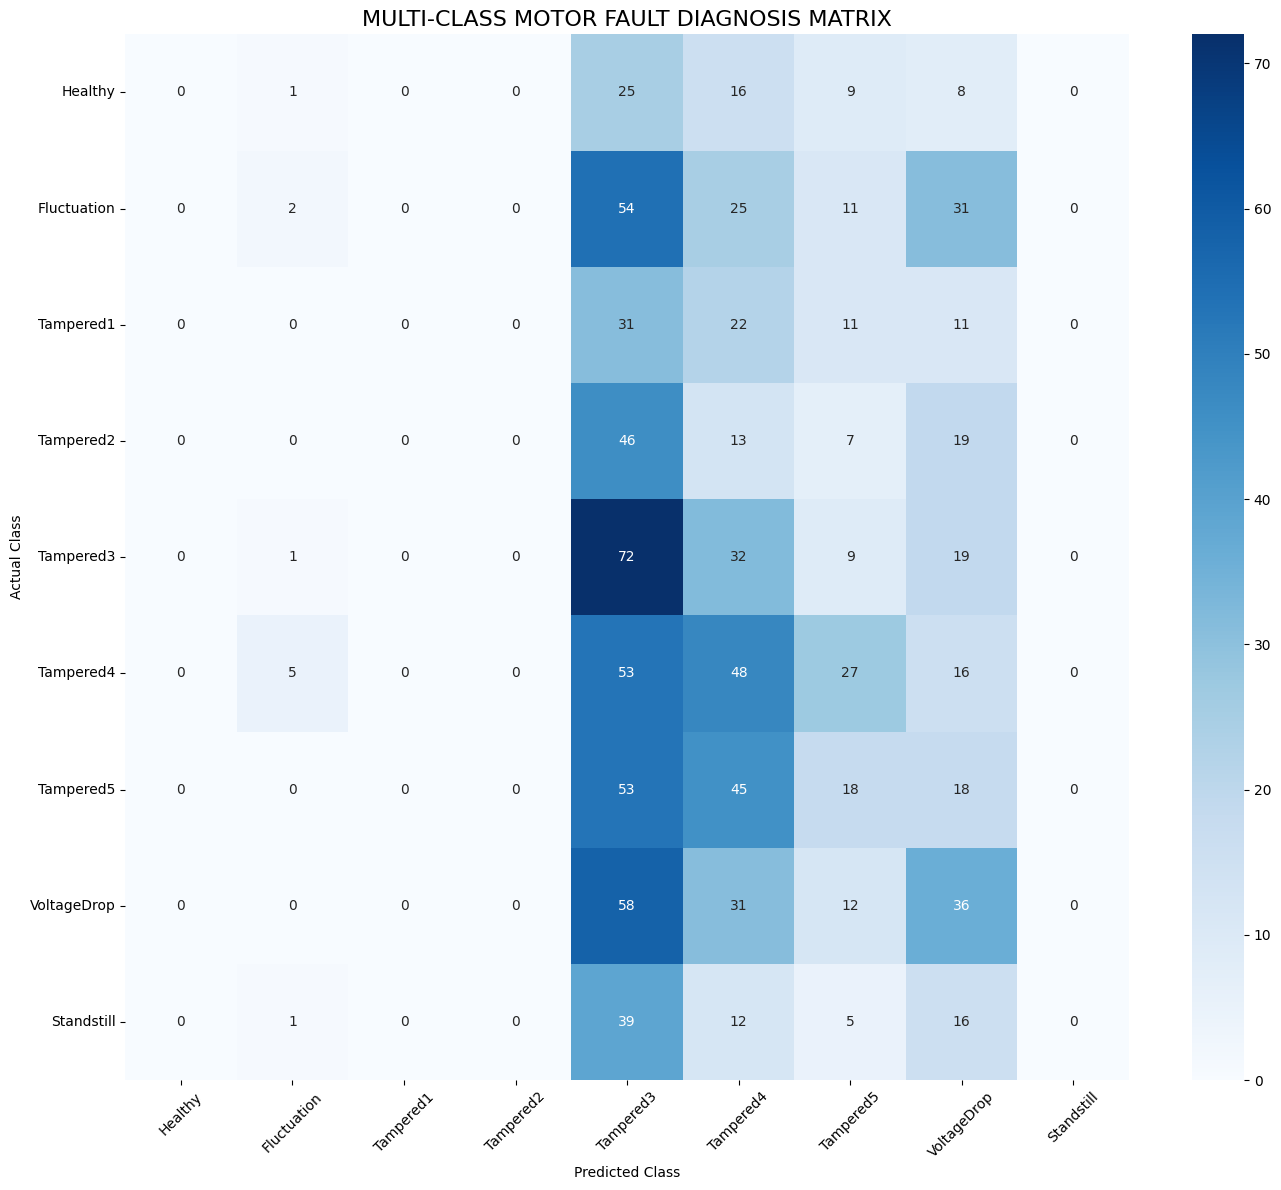


Running t-SNE visualization...



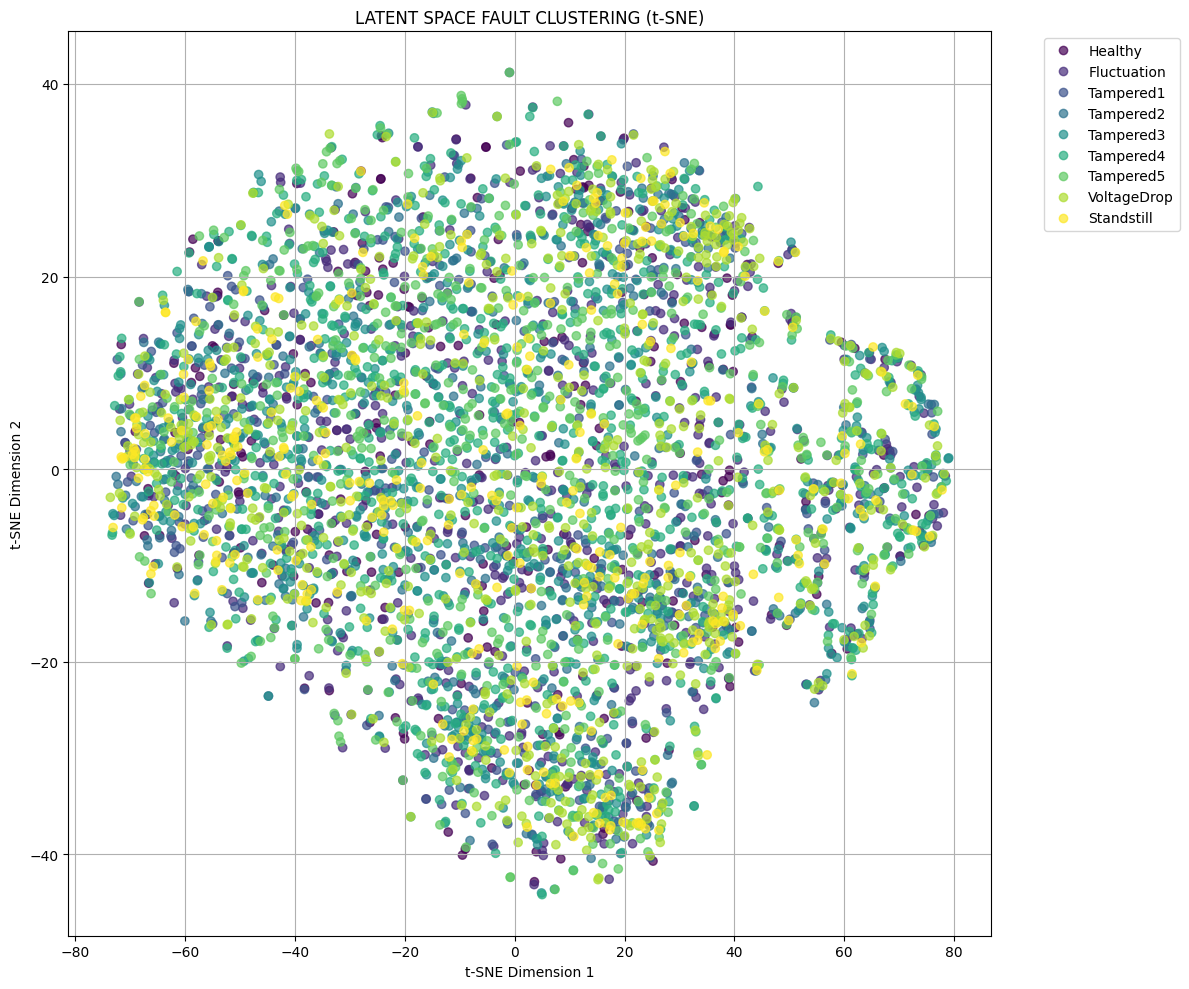


Generating reconstruction heatmap...



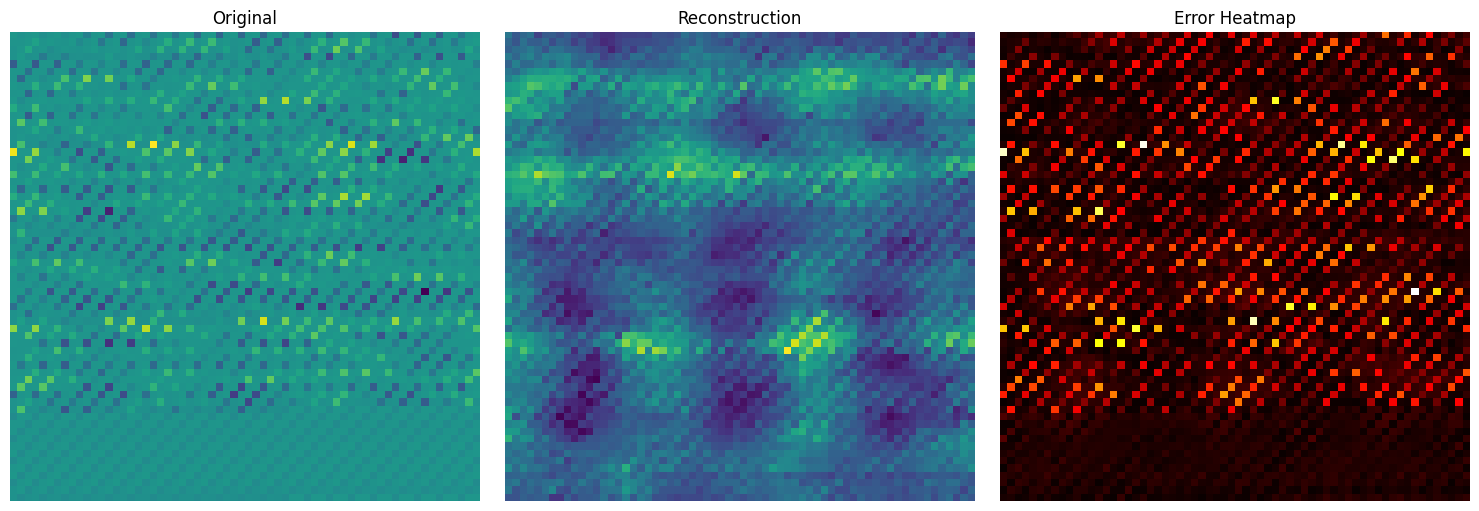

In [1]:
# =====================================================================
# GCDAE + MULTI-CLASS FAULT DIAGNOSIS SYSTEM
# =====================================================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from sklearn.model_selection import train_test_split


# =====================================================================
# 1. DATASET
# =====================================================================

class MotorDataset(Dataset):

    def __init__(
        self,
        file_dict,
        target_shape=(64, 64),
        baseline_mean=None,
        baseline_std=None
    ):

        self.data = []
        self.target_shape = target_shape

        row_size = target_shape[0] * target_shape[1]

        raw_list = []

        for name, path in file_dict.items():

            if not os.path.exists(path):
                print(f"Missing file: {path}")
                continue

            try:

                with open(path, 'r', encoding='utf-8', errors='ignore') as f:

                    for line in f:

                        cleaned_line = (
                            line.replace('\t', ',')
                                .replace(' ', ',')
                                .replace(';', ',')
                        )

                        parts = cleaned_line.strip().split(',')

                        for part in parts:

                            if not part:
                                continue

                            try:
                                raw_list.append(float(part))

                            except:
                                continue

            except Exception as e:
                print(f"Error parsing {path}: {e}")

        raw_numpy = np.array(raw_list, dtype=np.float32)

        # GLOBAL Z-SCORE NORMALIZATION

        if baseline_mean is not None and baseline_std is not None:

            self.mean = baseline_mean
            self.std = baseline_std

        else:

            self.mean = raw_numpy.mean()
            self.std = raw_numpy.std()

            if self.std < 1e-6:
                self.std = 1.0

        normalized = (raw_numpy - self.mean) / self.std

        num_samples = len(normalized) // row_size

        if num_samples == 0:
            raise ValueError("Insufficient data")

        normalized = normalized[:num_samples * row_size]

        self.data = normalized.reshape(
            num_samples,
            1,
            target_shape[0],
            target_shape[1]
        )

        print(f"Loaded {num_samples} frames")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        return torch.tensor(
            self.data[idx],
            dtype=torch.float32
        )


# =====================================================================
# 2. FILE MAPS
# =====================================================================

train_val_files = {
    "baseline": "baseline_motor_data.csv",
    "reassembled": "motor_running_bare_screw_positioned_again.csv"
}

test_files = {
    "fluctuations": "motor_running_bare_and_electrical_flactuations.csv",
    "tampered_1": "motor_running_bare_screw_fell_four.csv",
    "tampered_2": "motor_running_bare_screw_fell_three.csv",
    "tampered_3": "motor_running_bare_and_loose_a_bit.csv",
    "tampered_4": "motor_running_wheel_added.csv",
    "tampered_5": "motor_running_wheel_loosen_bit.csv",
    "voltage_drop": "motor_running_bare_and_voltage_drop_by_one.csv",
    "standstill": "no_motor_running.csv"
}


# =====================================================================
# 3. LABEL MAP
# =====================================================================

label_map = {

    "baseline": 0,
    "reassembled": 0,

    "fluctuations": 1,
    "tampered_1": 2,
    "tampered_2": 3,
    "tampered_3": 4,
    "tampered_4": 5,
    "tampered_5": 6,
    "voltage_drop": 7,
    "standstill": 8
}

class_names = [
    "Healthy",
    "Fluctuation",
    "Tampered1",
    "Tampered2",
    "Tampered3",
    "Tampered4",
    "Tampered5",
    "VoltageDrop",
    "Standstill"
]


# =====================================================================
# 4. INITIALIZE DATA
# =====================================================================

print("\nInitializing datasets...\n")

healthy_dataset = MotorDataset(
    train_val_files,
    target_shape=(64, 64)
)

baseline_mean = healthy_dataset.mean
baseline_std = healthy_dataset.std

train_size = int(0.8 * len(healthy_dataset))
val_size = len(healthy_dataset) - train_size

train_dataset, val_dataset = random_split(
    healthy_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loaders = {}

for case_name, path in test_files.items():

    if os.path.exists(path):

        ds = MotorDataset(
            {case_name: path},
            target_shape=(64, 64),
            baseline_mean=baseline_mean,
            baseline_std=baseline_std
        )

        test_loaders[case_name] = DataLoader(
            ds,
            batch_size=32,
            shuffle=False
        )


# =====================================================================
# 5. GCDAE MODEL
# =====================================================================

class GCDAE(nn.Module):

    def __init__(self):

        super(GCDAE, self).__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(1, 16, 3, 2, 1),
            nn.ReLU(),

            nn.Conv2d(16, 32, 3, 2, 1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, 2, 1),
            nn.ReLU()
        )

        self.fc_enc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU()
        )

        self.fc_dec = nn.Sequential(

            nn.Linear(32, 64 * 8 * 8),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                64,
                32,
                3,
                2,
                1,
                output_padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                32,
                16,
                3,
                2,
                1,
                output_padding=1
            ),

            nn.ReLU(),

            nn.ConvTranspose2d(
                16,
                1,
                3,
                2,
                1,
                output_padding=1
            )
        )

    def forward(self, x):

        z = self.encoder(x)

        z = self.fc_enc(z)

        x = self.fc_dec(z)

        x = x.view(x.size(0), 64, 8, 8)

        out = self.decoder(x)

        return out, z


# =====================================================================
# 6. TRAINING
# =====================================================================

def train_gcdae(model, loader, device, epochs=30):

    model.to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    criterion = nn.MSELoss()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for x in loader:

            x = x.to(device)

            recon, _ = model(x)

            loss = criterion(recon, x)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)

        print(
            f"Epoch {epoch+1:02d} "
            f"| Loss: {avg_loss:.6f}"
        )


# =====================================================================
# 7. LATENT FEATURE EXTRACTION
# =====================================================================

def extract_latent_features(
    model,
    loader,
    label,
    device
):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for x in loader:

            x = x.to(device)

            _, z = model(x)

            features.append(z.cpu().numpy())

            labels.extend([label] * len(z))

    features = np.vstack(features)

    return features, np.array(labels)


# =====================================================================
# 8. RECONSTRUCTION ERROR
# =====================================================================

def compute_recon_error(model, x, device):

    model.eval()

    with torch.no_grad():

        recon, _ = model(x.to(device))

        err = torch.mean(
            (recon - x.to(device)) ** 2,
            dim=(1, 2, 3)
        )

    return err.cpu().numpy()


# =====================================================================
# 9. TRAIN AUTOENCODER
# =====================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = GCDAE()

print("\nTraining GCDAE...\n")

train_gcdae(
    model,
    train_loader,
    device,
    epochs=30
)


# =====================================================================
# 10. BUILD LATENT DATASET
# =====================================================================

print("\nExtracting latent vectors...\n")

X_all = []
y_all = []

# HEALTHY

healthy_features, healthy_labels = extract_latent_features(
    model,
    val_loader,
    0,
    device
)

X_all.append(healthy_features)
y_all.append(healthy_labels)

# FAULT CASES

for case_name, loader in test_loaders.items():

    label = label_map[case_name]

    feats, labs = extract_latent_features(
        model,
        loader,
        label,
        device
    )

    X_all.append(feats)
    y_all.append(labs)

X_all = np.vstack(X_all)

y_all = np.concatenate(y_all)

print(f"Feature shape: {X_all.shape}")
print(f"Labels shape : {y_all.shape}")


# =====================================================================
# 11. TRAIN MULTI-CLASS CLASSIFIER
# =====================================================================

print("\nTraining SVM classifier...\n")

X_train, X_test, y_train, y_test = train_test_split(

    X_all,
    y_all,

    test_size=0.2,

    random_state=42,

    stratify=y_all
)

classifier = SVC(
    kernel='rbf'
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)


# =====================================================================
# 12. EVALUATION
# =====================================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n====================================")
print(f"Classification Accuracy: {accuracy:.4f}")
print("====================================\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)


# =====================================================================
# 13. MULTI-CLASS CONFUSION MATRIX
# =====================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names
)

plt.title(
    "MULTI-CLASS MOTOR FAULT DIAGNOSIS MATRIX",
    fontsize=16
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()


# =====================================================================
# 14. LATENT SPACE VISUALIZATION (t-SNE)
# =====================================================================

print("\nRunning t-SNE visualization...\n")

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_all)

plt.figure(figsize=(12, 10))

scatter = plt.scatter(

    X_tsne[:, 0],
    X_tsne[:, 1],

    c=y_all,

    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.title("LATENT SPACE FAULT CLUSTERING (t-SNE)")

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.grid(True)

plt.tight_layout()

plt.show()


# =====================================================================
# 15. RECONSTRUCTION ERROR HEATMAP
# =====================================================================

print("\nGenerating reconstruction heatmap...\n")

sample_batch = next(iter(val_loader))

sample = sample_batch[0:1].to(device)

model.eval()

with torch.no_grad():

    recon, _ = model(sample)

error_map = torch.abs(recon - sample)

sample_np = sample[0, 0].cpu().numpy()

recon_np = recon[0, 0].cpu().numpy()

error_np = error_map[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(sample_np, cmap='viridis')
axes[0].set_title("Original")

axes[1].imshow(recon_np, cmap='viridis')
axes[1].set_title("Reconstruction")

axes[2].imshow(error_np, cmap='hot')
axes[2].set_title("Error Heatmap")

for ax in axes:
    ax.axis('off')

plt.tight_layout()

plt.show()


# =====================================================================
# END
# =====================================================================